## Part 1 - Toy Dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

### Q1.a

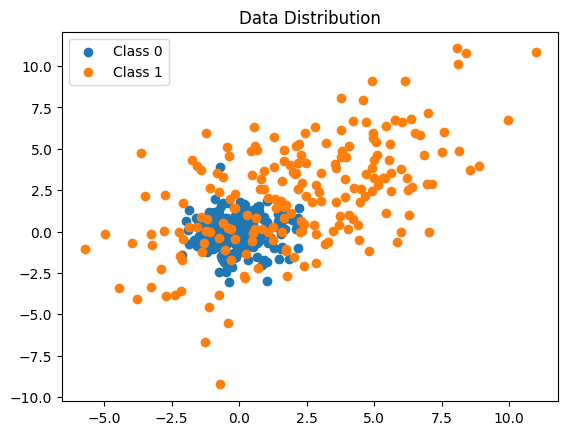

In [19]:
# Class 0: N([0, 0], I2)
mean0 = torch.tensor([0.0, 0.0])
cov0  = torch.eye(2)

# Class 1: N([2, 2], [[10, 5], [5, 10]])
mean1 = torch.tensor([2.0, 2.0])
cov1  = torch.tensor([[10.0, 5.0],
                      [ 5.0,10.0]])

dist0 = torch.distributions.MultivariateNormal(mean0, covariance_matrix=cov0)
dist1 = torch.distributions.MultivariateNormal(mean1, covariance_matrix=cov1)

n_per_class = 200
X0 = dist0.sample((n_per_class,))          # (200, 2)
X1 = dist1.sample((n_per_class,))          # (200, 2)

X = torch.cat([X0, X1], dim=0).to(torch.float32)
y = torch.cat([
    torch.zeros(n_per_class, dtype=torch.long),
    torch.ones(n_per_class,  dtype=torch.long)
])

plt.scatter(X0[:, 0], X0[:, 1], label='Class 0')
plt.scatter(X1[:, 0], X1[:, 1], label='Class 1')
plt.legend()
plt.title('Data Distribution')
plt.show()

### Q1.b et Q1.c

In [26]:
# Set random seed for reproducibility
g = torch.Generator().manual_seed(0)

X = torch.cat([X0, X1], dim=0).to(torch.float32)
y = torch.cat([
    torch.zeros(n_per_class, dtype=torch.long),
    torch.ones(n_per_class,  dtype=torch.long)
])

# shuffle data with fixed seed
perm = torch.randperm(len(X), generator=g)
X, y = X[perm], y[perm]

Training accuracy (QDA): 87.75%
(40000,)
(200, 200)


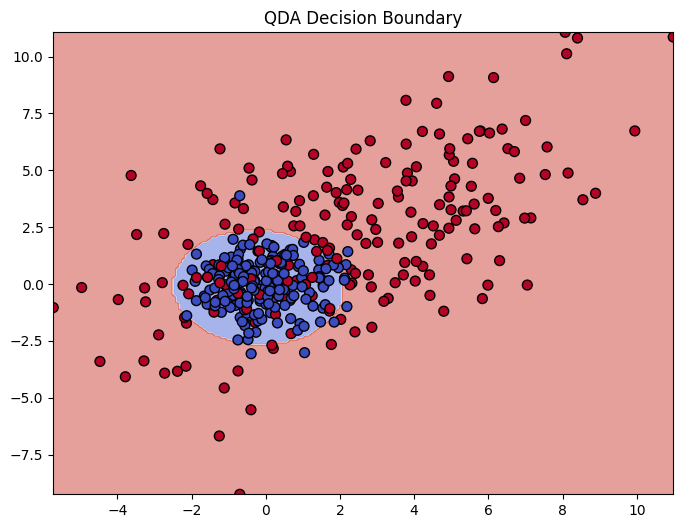

In [44]:
# Quadratic Discriminant Analysis model

clf = QuadraticDiscriminantAnalysis()
clf.fit(X, y)
print(f"Training accuracy (QDA): {clf.score(X, y)*100:.2f}%")

# plot decision boundary
plt.figure(figsize=(8, 6))
xx, yy = np.meshgrid(np.linspace(X[:, 0].min(), X[:, 0].max(), 200), np.linspace(X[:, 1].min(), X[:, 1].max(), 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]) # this gives a flat array of predictions for each point in the grid
print(Z.shape)
Z = Z.reshape(xx.shape) 
print(Z.shape)
plt.contourf(xx, yy, Z, alpha=0.5, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=50, cmap='coolwarm')
plt.title('QDA Decision Boundary')
plt.show()

### Analyse Discriminante Linéaire (LDA)

Fonction de régression:
$$
\eta_\theta(x)=\mathbb{Q}_\theta(Y=1\mid X=x)
= \frac{\pi_1\,e^{-\frac12(x-\mu_1)^\top\Sigma^{-1}(x-\mu_1)}}
{\pi_1\,e^{-\frac12(x-\mu_1)^\top\Sigma^{-1}(x-\mu_1)}
+ \pi_0\,e^{-\frac12(x-\mu_0)^\top\Sigma^{-1}(x-\mu_0)}}
= sigm(\phi_\theta(x))
$$

On en déduit que
$$
\phi_\theta(x)=(\mu_1-\mu_0)^\top \Sigma^{-1}x-\frac12\,\mu_1^\top\Sigma^{-1}\mu_1+\frac12\,\mu_0^\top\Sigma^{-1}\mu_0+\ln\!\Big(\frac{\pi_1}{\pi_0}\Big)=w_\theta^\top x + A_\theta
$$

La règle de décision bayésienne est
$$
g_\theta^\star(x)=\mathbf{1}\{\eta_\theta(x)\ge 1/2\}
=\mathbf{1}\{w_\theta^\top x + A_\theta \ge 0\}.
$$

La frontière de décision est un hyperplan normal à $w_\theta$ : d’un côté “classe $0$”, de l’autre “classe $1$”. C’est la LDA.

EMV consistants (ces résultats ont été obtenus dans l'exercice 3 de la PC8):

$$
\widehat{\pi}_{0,n}=\frac1n\sum_{k=1}^n \mathbf{1}\{Y_k=0\},\quad
\widehat{\mu}_{0,n}=\frac{\sum_{k=1}^n \mathbf{1}\{Y_k=0\}X_k}{\sum_{k=1}^n \mathbf{1}\{Y_k=0\}},\quad
\widehat{\mu}_{1,n}=\frac{\sum_{k=1}^n \mathbf{1}\{Y_k=1\}X_k}{\sum_{k=1}^n \mathbf{1}\{Y_k=1\}}.
$$
$$
\widehat{\Sigma}_n
=\frac1n\sum_{k=1}^n\Big[
\mathbf{1}\{Y_k=0\}(X_k-\widehat\mu_{0,n})(X_k-\widehat\mu_{0,n})^\top
+\mathbf{1}\{Y_k=1\}(X_k-\widehat\mu_{1,n})(X_k-\widehat\mu_{1,n})^\top
\Big]
$$

En remplaçant $\theta=(\pi_0,\pi_1,\mu_0,\mu_1,\Sigma)$ par ses EMV, on définit
$
\widehat \eta_n(x)=\mathrm{sigm}\big(\widehat \phi_n(x)\big),\qquad
\widehat \phi_n(x)=\widehat w_n^\top x + \widehat A_n,
$
avec
$
\widehat w_n=\widehat\Sigma_n^{-1}\big(\widehat\mu_{1,n}-\widehat\mu_{0,n}\big),\qquad
\widehat A_n=-\tfrac12\,\widehat\mu_{1,n}^\top\widehat\Sigma_n^{-1}\widehat\mu_{1,n}
+\tfrac12\,\widehat\mu_{0,n}^\top\widehat\Sigma_n^{-1}\widehat\mu_{0,n}
+\ln\!\Big(\tfrac{\widehat\pi_{1,n}}{\widehat\pi_{0,n}}\Big).
$

**Règle de prédiction (étiquettes $0/1$) :**
$
\widehat Y_n(x)=\mathbf{1}\{\widehat \eta_n(x)\ge\tfrac12\}
=\mathbf{1}\{\widehat w_n^\top x+\widehat A_n\ge 0\}.
$


In [49]:
# Linear Discriminant Analysis model

def fit_lda(X: torch.Tensor, y: torch.Tensor):
    X = X.to(torch.float64)
    y = y.to(torch.long)

    mask0 = (y == 0) 
    mask1 = ~mask0
    n = X.shape[0]
    n0 = mask0.sum().item() # number of class 0 samples
    n1 = mask1.sum().item()

    # Priors (EMV)
    pi0_hat = n0 / n
    pi1_hat = n1 / n

    # Class means (EMV)
    mu0_hat = X[mask0].mean(dim=0)
    mu1_hat = X[mask1].mean(dim=0)

    # Pooled covariance (EMV with 1/n)
    X0_c = X[mask0] - mu0_hat
    X1_c = X[mask1] - mu1_hat
    # (n x d)^T @ (n x d) -> (d x d)
    S0 = X0_c.T @ X0_c
    S1 = X1_c.T @ X1_c
    Sigma_hat = (S0 + S1) / n

    # Inverse covariance
    Sigma_inv = torch.linalg.inv(Sigma_hat)

    # w_hat and A_hat
    delta_mu = (mu1_hat - mu0_hat)                   # (d,)
    w_hat = Sigma_inv @ delta_mu                     # (d,)
    A_hat = (
        -0.5 * (mu1_hat @ (Sigma_inv @ mu1_hat))
        + 0.5 * (mu0_hat @ (Sigma_inv @ mu0_hat))
        + torch.log(torch.tensor(pi1_hat / pi0_hat, dtype=X.dtype))
    )

    return {
        "pi0": pi0_hat, "pi1": pi1_hat,
        "mu0": mu0_hat, "mu1": mu1_hat,
        "Sigma": Sigma_hat, "Sigma_inv": Sigma_inv,
        "w_hat": w_hat, "A_hat": A_hat
    }

def lda_phi(X: torch.Tensor, params: dict) -> torch.Tensor:
    """ phi_hat(x) = w^T x + A, vectorized over rows of X. """
    X = X.to(torch.float64)
    return X @ params["w_hat"] + params["A_hat"]

def lda_predict(X: torch.Tensor, params: dict) -> torch.Tensor:
    """ Class prediction 0/1 using sign of phi (or eta >= 1/2). """
    phi = lda_phi(X, params)
    return (phi >= 0).to(torch.long)

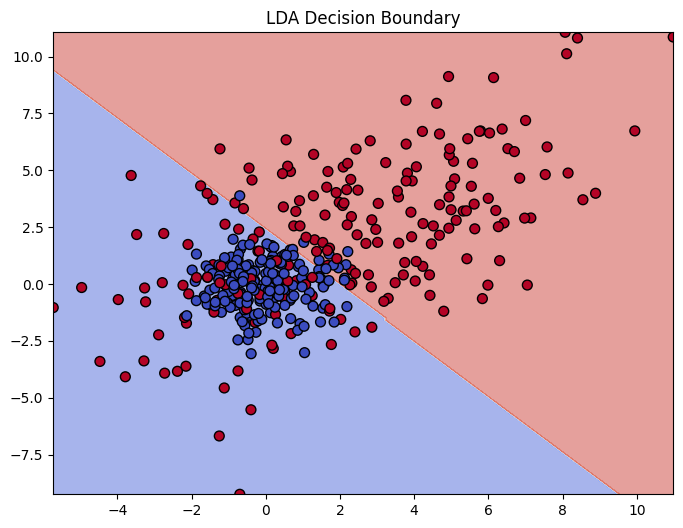

In [51]:
params = fit_lda(X, y)

# plot decision boundary
plt.figure(figsize=(8, 6))
xx, yy = np.meshgrid(np.linspace(X[:, 0].min(), X[:, 0].max(), 200), np.linspace(X[:, 1].min(), X[:, 1].max(), 200))
# predict on grid points
points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float64)
Z = lda_predict(points, params)
Z = Z.reshape(xx.shape) 
plt.contourf(xx, yy, Z, alpha=0.5, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=50, cmap='coolwarm')
plt.title('LDA Decision Boundary')
plt.show()

### Q1.d

## Part 2 - Classification on MNIST

### Q2.a

In [22]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score

transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

X = torch.cat([train_data.data, test_data.data]).float() / 255.0
y = torch.cat([train_data.targets, test_data.targets])
y_binary = (y % 2 != 0).long()  # 0=even, 1=odd

### Q2.b

### Q2.c

### Q2.d

### Q2.e 

In [23]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(nn.Linear(32*7*7, 64), nn.ReLU(), nn.Linear(64, 1))
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        h = self.fc[0:2](x)  # penultimate activations
        out = self.fc[2](h)
        return out, h

model = SmallCNN()
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()

dataset = TensorDataset(X.unsqueeze(1), y_binary.float())
loader = DataLoader(dataset, batch_size=128, shuffle=True)

n_epochs = 5
model.train()

for epoch in range(n_epochs):
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out, _ = model(xb)
        train_loss = loss_fn(out.squeeze(), yb)
        opt.zero_grad()
        train_loss.backward()
        opt.step()
        
    print(f"Epoch {epoch+1}, loss={train_loss.item():.4f}")

Epoch 1, loss=0.0278
Epoch 2, loss=0.0176
Epoch 3, loss=0.0330
Epoch 4, loss=0.0385
Epoch 5, loss=0.0566


### Q2.f

### Q2.g